# 02 — Weather Data Integration

## Objective
Fetch weather for all 23 active store cities and merge onto the weekly units table.

## Data Sources
- Open-Meteo Archive API — historical daily weather (free, no key needed)
- Open-Meteo Forecast API — up to 16 days ahead
- python-holidays — QC + ON statutory holidays

## Input
- `data/processed/weekly_units.csv`

## Output
- `data/processed/weather_by_city_week.csv`
- `data/processed/weekly_units_weather.csv`


---
## Cell 1 — Imports
---

In [1]:
import pandas as pd
import numpy as np
import requests
import holidays as holidays_lib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, time
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_palette('husl')

PROJECT_ROOT   = Path('..')
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
print('✅ Imports complete')

✅ Imports complete


---
## Cell 2 — Load Data & City Coordinates
---

In [2]:
weekly = pd.read_csv(DATA_PROCESSED / 'weekly_units.csv')
weekly['week_ending'] = pd.to_datetime(weekly['week_ending'])
print(f'Weekly units loaded: {weekly.shape}')

# Full coordinates for all active stores
# Stores in the same city automatically share one weather fetch
CITY_COORDS = {
    'Québec':                   {'lat': 46.8139, 'lon': -71.2080, 'province': 'QC'},
    'Blainville':               {'lat': 45.6700, 'lon': -73.8800, 'province': 'QC'},
    'Drummondville':            {'lat': 45.8836, 'lon': -72.4853, 'province': 'QC'},
    'Sherbrooke':               {'lat': 45.4042, 'lon': -71.8929, 'province': 'QC'},
    'Granby':                   {'lat': 45.3987, 'lon': -72.7284, 'province': 'QC'},
    'Laval':                    {'lat': 45.6066, 'lon': -73.7124, 'province': 'QC'},
    'Longueuil':                {'lat': 45.5317, 'lon': -73.5180, 'province': 'QC'},
    'Saint-Jérôme':             {'lat': 45.7794, 'lon': -74.0031, 'province': 'QC'},
    'Vaudreuil-Dorion':         {'lat': 45.3985, 'lon': -74.0297, 'province': 'QC'},
    'St-Georges-de-Beauce':     {'lat': 46.1175, 'lon': -70.6650, 'province': 'QC'},
    'Victoriaville':            {'lat': 46.0581, 'lon': -71.9567, 'province': 'QC'},
    'Repentigny':               {'lat': 45.7400, 'lon': -73.4600, 'province': 'QC'},
    'Chicoutimi':               {'lat': 48.4220, 'lon': -71.0669, 'province': 'QC'},
    'Trois-Rivières':           {'lat': 46.3432, 'lon': -72.5418, 'province': 'QC'},
    "Val-d'Or":                 {'lat': 48.0966, 'lon': -77.7789, 'province': 'QC'},
    'Valleyfield':              {'lat': 45.2536, 'lon': -74.1280, 'province': 'QC'},
    'Nepean':                   {'lat': 45.3192, 'lon': -75.7166, 'province': 'ON'},
    'Pointe-aux-Trembles':      {'lat': 45.6600, 'lon': -73.5000, 'province': 'QC'},
    'Lévis':                    {'lat': 46.8038, 'lon': -71.1750, 'province': 'QC'},
    'St-Hyacinthe':             {'lat': 45.6298, 'lon': -72.9588, 'province': 'QC'},
    'Sorel-Tracy':              {'lat': 46.0426, 'lon': -73.1152, 'province': 'QC'},
    'Saint-Jean-sur-Richelieu': {'lat': 45.3063, 'lon': -73.2605, 'province': 'QC'},
    'Saint-Eustache':           {'lat': 45.5700, 'lon': -73.9100, 'province': 'QC'},
    'Gatineau':                 {'lat': 45.4765, 'lon': -75.7013, 'province': 'QC'},
    'Joliette':                 {'lat': 46.0178, 'lon': -73.4382, 'province': 'QC'},
    'Thetford Mines':           {'lat': 46.0520, 'lon': -71.2990, 'province': 'QC'},
    'Ste-Foy':                  {'lat': 46.7690, 'lon': -71.2890, 'province': 'QC'},
    'St-Constant':              {'lat': 45.3688, 'lon': -73.5698, 'province': 'QC'},
    'Cowansville':              {'lat': 45.2000, 'lon': -72.7500, 'province': 'QC'},
    'Sainte-Agathe-des-Monts':  {'lat': 46.0500, 'lon': -74.2833, 'province': 'QC'},
    'Riviere-du-Loup':          {'lat': 47.8333, 'lon': -69.5333, 'province': 'QC'},
    'Beloeil':                  {'lat': 45.5638, 'lon': -73.2052, 'province': 'QC'},
}

START_DATE    = weekly['week_ending'].min().strftime('%Y-%m-%d')
END_DATE      = '2026-03-08'
FORECAST_DAYS = 16

print(f'Cities        : {len(CITY_COORDS)}')
print(f'Historical    : {START_DATE} → {END_DATE}')
print(f'Forward days  : {FORECAST_DAYS}')

Weekly units loaded: (49148, 9)
Cities        : 32
Historical    : 2023-11-05 → 2026-03-08
Forward days  : 16


---
## Cell 3 — Weather Classification (WMO Codes → Labels)
---

In [3]:
def classify_weather(df):
    def get_condition(code):
        if   code == 0:             return 'Clear'
        elif code in range(1,4):    return 'Cloudy'
        elif code in range(45,50):  return 'Fog'
        elif code in range(51,68):  return 'Rain'
        elif code in range(71,78):  return 'Snow'
        elif code in range(80,83):  return 'Rain'
        elif code in range(85,87):  return 'Snow'
        elif code in range(95,100): return 'Thunderstorm'
        else:                       return 'Other'
    df = df.copy()
    df['weather_condition'] = df['weathercode'].apply(get_condition)
    df['is_rain']           = (df['weather_condition'] == 'Rain').astype(int)
    df['is_snow']           = (df['weather_condition'] == 'Snow').astype(int)
    df['is_bad_weather']    = df['weather_condition'].isin(
                                  ['Rain','Thunderstorm','Snow']).astype(int)
    return df

print('✅ classify_weather() ready')

✅ classify_weather() ready


---
## Cell 4 — Fetch Historical Weather (all cities)
---

In [4]:
import time

def fetch_historical_weather(city, lat, lon, start, end, retries=4):
    params = {
        'latitude': lat, 'longitude': lon,
        'start_date': start, 'end_date': end,
        'daily': ['temperature_2m_mean','temperature_2m_max',
                  'precipitation_sum','weathercode','sunshine_duration',
                  'wind_speed_10m_max','apparent_temperature_max'],
        'timezone': 'America/Toronto'
    }
    for attempt in range(retries):
        try:
            r = requests.get('https://archive-api.open-meteo.com/v1/archive',
                             params=params, timeout=30)
            r.raise_for_status()
            d  = r.json()['daily']
            df = pd.DataFrame({
                'date':           pd.to_datetime(d['time']),
                'temp_mean':      d['temperature_2m_mean'],
                'temp_max':       d['temperature_2m_max'],
                'precipitation':  d['precipitation_sum'],
                'weathercode':    [int(c) for c in d['weathercode']],
                'sunshine_hours': [s/3600 if s else 0 for s in d['sunshine_duration']],
                'wind_max':       d.get('wind_speed_10m_max', [0]*len(d['time'])),
                'apparent_temp_max': d.get('apparent_temperature_max', [0]*len(d['time'])),
                'city': city
            }).fillna(0)
            return classify_weather(df)

        except Exception as e:
            if '429' in str(e):
                wait = 60 * (attempt + 1)   # 60s → 120s → 180s → 240s
                print(f'    ⏳ Rate limited. Waiting {wait}s before retry {attempt+1}/{retries}...')
                time.sleep(wait)
            else:
                raise   # Non-rate-limit errors bubble up immediately

    raise Exception(f'Failed after {retries} retries')

all_hist = []
for city, coords in CITY_COORDS.items():
    try:
        df_w = fetch_historical_weather(city, coords['lat'], coords['lon'], START_DATE, END_DATE)
        all_hist.append(df_w)
        print(f'  ✓ {city}  ({len(df_w)} days)')
        time.sleep(2)   # 2s between every request — well within free tier limits
    except Exception as e:
        print(f'  ✗ {city} — {e}')

weather_daily = pd.concat(all_hist, ignore_index=True)
print(f'\n✅ Historical: {len(weather_daily):,} records | {weather_daily["city"].nunique()} cities')

  ✓ Québec  (855 days)
  ✓ Blainville  (855 days)
  ✓ Drummondville  (855 days)
  ✓ Sherbrooke  (855 days)
  ✓ Granby  (855 days)
  ✓ Laval  (855 days)
  ✓ Longueuil  (855 days)
  ✓ Saint-Jérôme  (855 days)
  ✓ Vaudreuil-Dorion  (855 days)
  ✓ St-Georges-de-Beauce  (855 days)
  ✓ Victoriaville  (855 days)
  ✓ Repentigny  (855 days)
  ✓ Chicoutimi  (855 days)
  ✓ Trois-Rivières  (855 days)
  ✓ Val-d'Or  (855 days)
  ✓ Valleyfield  (855 days)
  ✓ Nepean  (855 days)
  ✓ Pointe-aux-Trembles  (855 days)
  ✓ Lévis  (855 days)
  ✓ St-Hyacinthe  (855 days)
  ✓ Sorel-Tracy  (855 days)
  ✓ Saint-Jean-sur-Richelieu  (855 days)
  ✓ Saint-Eustache  (855 days)
  ✓ Gatineau  (855 days)
    ⏳ Rate limited. Waiting 60s before retry 1/4...
  ✓ Joliette  (855 days)
  ✓ Thetford Mines  (855 days)
  ✓ Ste-Foy  (855 days)
  ✓ St-Constant  (855 days)
  ✓ Cowansville  (855 days)
  ✓ Sainte-Agathe-des-Monts  (855 days)
  ✓ Riviere-du-Loup  (855 days)
  ✓ Beloeil  (855 days)

✅ Historical: 27,360 records | 32 c

---
## Cell 5 — Fetch Forward Forecast
---

In [5]:
def fetch_forecast_weather(city, lat, lon, days=16):
    params = {
        'latitude': lat, 'longitude': lon, 'forecast_days': days,
        'daily': ['temperature_2m_mean','temperature_2m_max',
                  'precipitation_sum','weathercode','sunshine_duration',
                  'wind_speed_10m_max','apparent_temperature_max'],
        'timezone': 'America/Toronto'
    }
    r  = requests.get('https://api.open-meteo.com/v1/forecast',
                      params=params, timeout=30)
    r.raise_for_status()
    d  = r.json()['daily']
    df = pd.DataFrame({
        'date':           pd.to_datetime(d['time']),
        'temp_mean':      d['temperature_2m_mean'],
        'temp_max':       d['temperature_2m_max'],
        'precipitation':  d['precipitation_sum'],
        'weathercode':    [int(c) for c in d['weathercode']],
        'sunshine_hours': [s/3600 if s else 0 for s in d['sunshine_duration']],
        'wind_max':       d.get('wind_speed_10m_max', [0]*len(d['time'])),
        'apparent_temp_max': d.get('apparent_temperature_max', [0]*len(d['time'])),
        'city': city
    }).fillna(0)
    return classify_weather(df)

all_fcast = []
for city, coords in CITY_COORDS.items():
    try:
        df_w = fetch_forecast_weather(city, coords['lat'], coords['lon'], FORECAST_DAYS)
        all_fcast.append(df_w)
        print(f'  ✓ {city}')
        time.sleep(0.3)
    except Exception as e:
        print(f'  ✗ {city} — {e}')

weather_fcast_daily = pd.concat(all_fcast, ignore_index=True)
print(f'\n✅ Forecast: {len(weather_fcast_daily):,} records')

  ✓ Québec
  ✓ Blainville
  ✓ Drummondville
  ✓ Sherbrooke
  ✓ Granby
  ✓ Laval
  ✓ Longueuil
  ✓ Saint-Jérôme
  ✓ Vaudreuil-Dorion
  ✓ St-Georges-de-Beauce
  ✓ Victoriaville
  ✓ Repentigny
  ✓ Chicoutimi
  ✓ Trois-Rivières
  ✓ Val-d'Or
  ✓ Valleyfield
  ✓ Nepean
  ✓ Pointe-aux-Trembles
  ✓ Lévis
  ✓ St-Hyacinthe
  ✓ Sorel-Tracy
  ✓ Saint-Jean-sur-Richelieu
  ✓ Saint-Eustache
  ✓ Gatineau
  ✓ Joliette
  ✓ Thetford Mines
  ✓ Ste-Foy
  ✓ St-Constant
  ✓ Cowansville
  ✓ Sainte-Agathe-des-Monts
  ✓ Riviere-du-Loup
  ✓ Beloeil

✅ Forecast: 512 records


---
## Cell 5b — Weekend Flag & Day Count for Partial-Week Handling
---

In [6]:
# Combine historical and forecast daily data
weather_all_daily = pd.concat([weather_daily, weather_fcast_daily], ignore_index=True)
weather_all_daily = weather_all_daily.drop_duplicates(subset=['city', 'date'], keep='first')

# Weekend flag (Saturday=5, Sunday=6)
weather_all_daily['is_weekend'] = weather_all_daily['date'].dt.dayofweek.isin([5, 6]).astype(int)

# Week ending (Sunday)
weather_all_daily['week_ending'] = weather_all_daily['date'] + pd.offsets.Week(weekday=6)

# Count days per city-week for partial week handling
days_per_week = (
    weather_all_daily.groupby(['city', 'week_ending'])
    .size()
    .reset_index(name='n_days_in_week')
)

print(f"✅ Weekend flags added | Partial weeks (< 7 days): {(days_per_week['n_days_in_week'] < 7).sum()}")

✅ Weekend flags added | Partial weeks (< 7 days): 64


---
## Cell 6 — Aggregate to Weekly
---

In [7]:
def aggregate_weather_weekly(df):
    agg_dict = {
        'avg_temp':         ('temp_mean',          'mean'),
        'max_temp':         ('temp_max',            'mean'),
        'total_precip':     ('precipitation',       'sum'),
        'sunshine_hours':   ('sunshine_hours',      'sum'),
        'rain_days':        ('is_rain',             'sum'),
        'snow_days':        ('is_snow',             'sum'),
        'bad_weather_days': ('is_bad_weather',      'sum'),
        'max_wind':         ('wind_max',            'max'),
        'feels_like_max':   ('apparent_temp_max',   'mean'),
    }
    
    result = (
        df.set_index('date').groupby('city').resample('W')
          .agg(**agg_dict)
          .reset_index()
          .rename(columns={'date': 'week_ending'})
    )
    return result


def aggregate_weekend_weather(df):
    """Aggregate weekend-only weather per city-week."""
    weekend = df[df['is_weekend'] == 1].copy()
    if len(weekend) == 0:
        return pd.DataFrame()
    
    result = (
        weekend.set_index('date').groupby('city').resample('W')
        .agg(
            weekend_avg_temp      = ('temp_mean',     'mean'),
            weekend_bad_weather   = ('is_bad_weather', 'sum'),
        )
        .reset_index()
        .rename(columns={'date': 'week_ending'})
    )
    return result


# Run aggregation on combined daily data
hist_weekly  = aggregate_weather_weekly(weather_daily)
fcast_weekly = aggregate_weather_weekly(weather_fcast_daily)

weather_weekly = (
    pd.concat([hist_weekly, fcast_weekly], ignore_index=True)
      .drop_duplicates(subset=['city','week_ending'])
      .sort_values(['city','week_ending']).reset_index(drop=True)
)

# Weekend weather
weekend_weekly = aggregate_weekend_weather(weather_all_daily)

# Merge weekend weather and day counts
if len(weekend_weekly) > 0:
    weather_weekly = weather_weekly.merge(weekend_weekly, on=['city', 'week_ending'], how='left')
weather_weekly = weather_weekly.merge(days_per_week, on=['city', 'week_ending'], how='left')
weather_weekly['n_days_in_week'] = weather_weekly['n_days_in_week'].fillna(7).astype(int)

# Fill weekend NaNs (partial weeks with no weekend days)
for col in ['weekend_avg_temp', 'weekend_bad_weather']:
    if col in weather_weekly.columns:
        weather_weekly[col] = weather_weekly[col].fillna(0)

# Fix partial-week bias for SUM features
SUM_COLS = ['total_precip', 'sunshine_hours', 'rain_days', 'snow_days', 'bad_weather_days']
for col in SUM_COLS:
    if col in weather_weekly.columns:
        mask = weather_weekly['n_days_in_week'] < 7
        weather_weekly.loc[mask, col] = (
            weather_weekly.loc[mask, col] * 7 / weather_weekly.loc[mask, 'n_days_in_week']
        )

weather_weekly[weather_weekly.select_dtypes(float).columns] = \
    weather_weekly.select_dtypes(float).round(2)

print(f'Weekly weather: {weather_weekly.shape}  |  Cities: {weather_weekly["city"].nunique()}')
print(f'New columns: max_wind, feels_like_max, weekend_avg_temp, weekend_bad_weather, n_days_in_week')

Weekly weather: (4032, 14)  |  Cities: 32
New columns: max_wind, feels_like_max, weekend_avg_temp, weekend_bad_weather, n_days_in_week


---
## Cell 7 — Quebec & Ontario Holidays
---

In [8]:
years_in_data  = sorted(weekly['week_ending'].dt.year.unique().tolist())
city_province  = {city: v['province'] for city, v in CITY_COORDS.items()}

hol_records = []
for prov in ['QC', 'ON']:
    for date, name in holidays_lib.Canada(prov=prov, years=years_in_data).items():
        hol_records.append({'date': pd.Timestamp(date), 'holiday': name, 'province': prov})

holidays_df = pd.DataFrame(hol_records)
holidays_df['week_ending'] = holidays_df['date'] + pd.offsets.Week(weekday=6)

city_prov_df   = pd.DataFrame([{'city': c, 'province': p} for c, p in city_province.items()])
holiday_weekly = (
    holidays_df.merge(city_prov_df, on='province')
               .groupby(['city','week_ending'])
               .agg(n_holidays=('holiday','count'), has_holiday=('holiday', lambda x: 1))
               .reset_index()
)
print(f'✅ {len(holidays_df)} holiday records  (QC + ON, {years_in_data})')

✅ 70 holiday records  (QC + ON, [2023, 2024, 2025, 2026])


---
## Cell 8 — Merge Weather + Holidays onto Weekly Units
---

In [9]:
weekly_weather = weekly.merge(weather_weekly, on=['city','week_ending'], how='left')
weekly_weather = weekly_weather.merge(
    holiday_weekly[['city','week_ending','n_holidays','has_holiday']],
    on=['city','week_ending'], how='left'
)
weekly_weather['n_holidays']  = weekly_weather['n_holidays'].fillna(0).astype(int)
weekly_weather['has_holiday'] = weekly_weather['has_holiday'].fillna(0).astype(int)

# Fill weather gaps with monthly city median
weekly_weather['month'] = weekly_weather['week_ending'].dt.month
for col in ['avg_temp','total_precip','rain_days','snow_days','bad_weather_days','sunshine_hours']:
    if col in weekly_weather.columns:
        med = weekly_weather.groupby(['city','month'])[col].transform('median')
        weekly_weather[col] = weekly_weather[col].fillna(med)

fill_rate = weekly_weather['avg_temp'].notna().mean() * 100
print(f'Shape      : {weekly_weather.shape}')
print(f'Fill rate  : {fill_rate:.1f}%')
print(f'Remaining nulls (avg_temp): {weekly_weather["avg_temp"].isna().sum()}')

Shape      : (49148, 24)
Fill rate  : 100.0%
Remaining nulls (avg_temp): 0


---
## Cell 9 — Weather vs Units Visualizations
---

KeyboardInterrupt: 

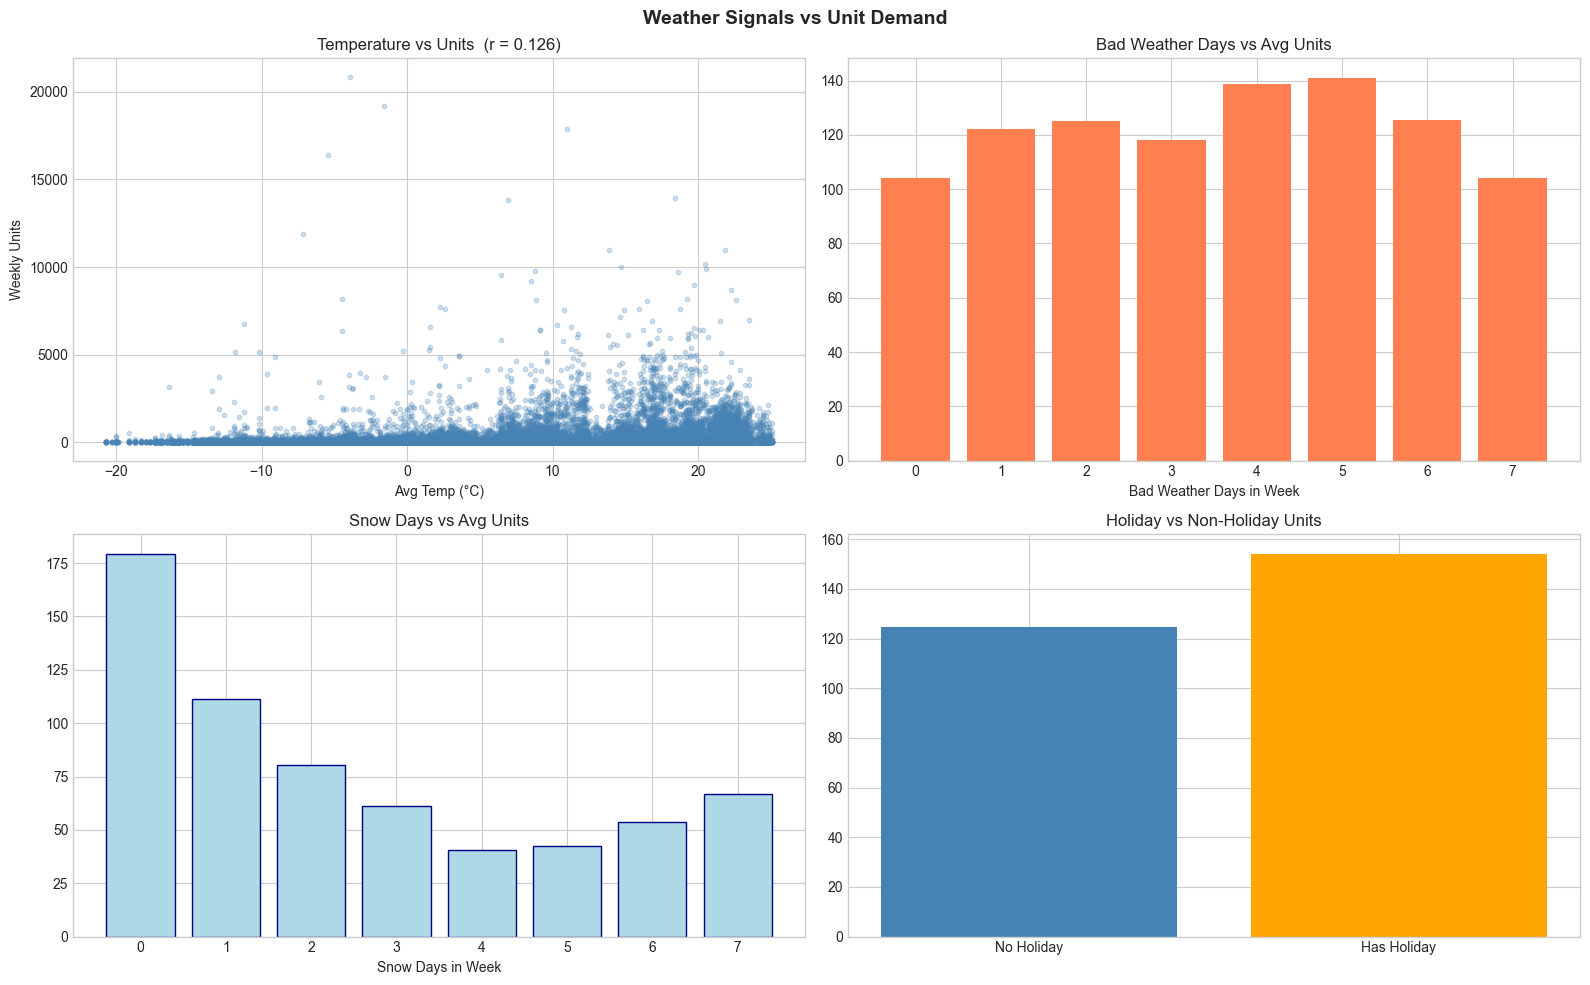

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

corr = weekly_weather['avg_temp'].corr(weekly_weather['units'])
axes[0,0].scatter(weekly_weather['avg_temp'], weekly_weather['units'],
                  alpha=0.25, s=10, color='steelblue')
axes[0,0].set_title(f'Temperature vs Units  (r = {corr:.3f})')
axes[0,0].set_xlabel('Avg Temp (°C)'); axes[0,0].set_ylabel('Weekly Units')

bw = weekly_weather.groupby('bad_weather_days')['units'].mean()
axes[0,1].bar(bw.index, bw.values, color='coral')
axes[0,1].set_title('Bad Weather Days vs Avg Units')
axes[0,1].set_xlabel('Bad Weather Days in Week')

sn = weekly_weather.groupby('snow_days')['units'].mean()
axes[1,0].bar(sn.index, sn.values, color='lightblue', edgecolor='navy')
axes[1,0].set_title('Snow Days vs Avg Units')
axes[1,0].set_xlabel('Snow Days in Week')

hol = weekly_weather.groupby('has_holiday')['units'].mean()
axes[1,1].bar(['No Holiday','Has Holiday'], hol.values, color=['steelblue','orange'])
axes[1,1].set_title('Holiday vs Non-Holiday Units')

plt.suptitle('Weather Signals vs Unit Demand', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'weather_vs_units.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: weather_vs_units.png')

---
## Cell 10 — Save
---

In [11]:
# Compatibility assertion — ensure NB03/NB04 required columns are present
REQUIRED_COLS = ['week_ending','store_code','city','province','division_code',
                 'units','gross_units','returns','n_transactions',
                 'avg_temp','max_temp','total_precip','sunshine_hours',
                 'rain_days','snow_days','bad_weather_days','n_holidays','has_holiday','month']
missing = [c for c in REQUIRED_COLS if c not in weekly_weather.columns]
assert not missing, f"Missing required columns: {missing}"
print(f"✅ Compatibility check passed ({len(REQUIRED_COLS)} required columns present)")

weather_weekly.to_csv(DATA_PROCESSED / 'weather_by_city_week.csv', index=False)
weekly_weather.to_csv(DATA_PROCESSED / 'weekly_units_weather.csv', index=False)
print(f'✅ weather_by_city_week.csv    {weather_weekly.shape}')
print(f'✅ weekly_units_weather.csv   {weekly_weather.shape}')
print('Next → 03_feature_engineering.ipynb')

✅ Compatibility check passed (19 required columns present)
✅ weather_by_city_week.csv    (4032, 14)
✅ weekly_units_weather.csv   (49148, 24)
Next → 03_feature_engineering.ipynb
